In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Beyond .plot(), other ways of visualizing data

We have now learned how to customize our plot, but often times the type of plot we have chosen for our data simply isn't very well suited.

For instance, if the goal in analyzing our above data is to visually express  how many times a particular number has occured in one array versus the other, and not care too much about the dependence in between numbers, a histogram may be a better choice. (Similar barplots would also be a better choice if we cared about comparing categories.)

We can make use of the .hist() function for this purpose, with most other parts previously explained staying the same

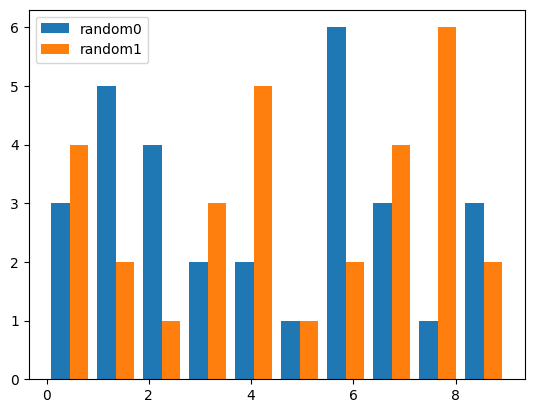

In [15]:
random_data = np.array([np.random.randint(0,10,30), np.random.randint(0,10,30)])

fig = plt.figure()
plt.hist([random_data[0],random_data[1]], bins=10, label=["random0", "random1"])
# Note that we can also express things like label strings in
# .plot() or .hist() directly, as opposed to in the legend call
plt.legend(frameon=True)

We can double check if this is correct and also identify which specific indices correspond to a particular value using the np.argwhere() function. We'll do this for the value 0 as an example.

In [31]:
argwhere = np.argwhere(random_data[0] == 0)
print(argwhere)

print(random_data[0][argwhere])

[[11]
 [16]
 [28]]
[[0]
 [0]
 [0]]


There are many many more styles of plot available. Let's look at one more, to have the basics cover and then move on to how plotting can also be viewed from an object-oriented coding style.

The particular plot we'll visit is the scatter plot, which is useful when facing many individual data points to visualize trends, similar to how the histogram visualizes some statistical properties. Let us draw some random numbers and visualize them

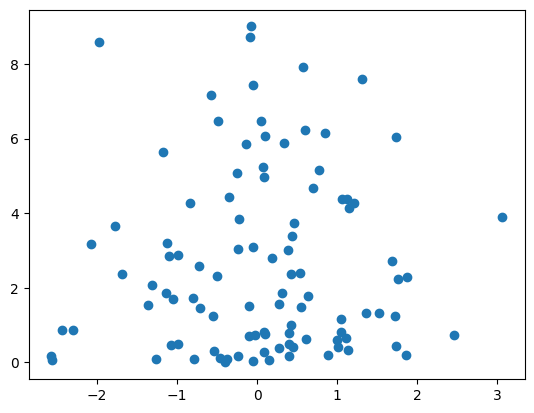

In [58]:
N = 100
ran_data = [np.random.randn(N), np.random.rand(N) * np.arange(0,10,10/N)]

fig = plt.figure()
plt.scatter(x=ran_data[0], y=ran_data[1])
plt.show()

At the core, this is different from our previous line plots, where the x-axis has simply counted up numbers so far and we now visualize the elements of a two-dimensional array.

As before, we should label the axes and we can improve markers. Scatter plots also allow us to encode information in terms of the size of the marker. Here is an example with made up size of the marker

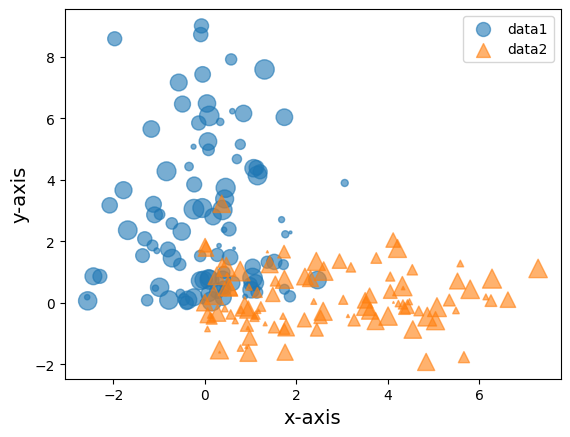

In [81]:
ran_data2 = [np.random.rand(N) * np.arange(0,10,10/N), np.random.randn(N)]
scale1 = 200 * np.random.rand(N)
scale2 = 200 * np.random.rand(N)

fig = plt.figure()
plt.scatter(x=ran_data[0], y=ran_data[1], marker='o', s=scale1,
            alpha=0.6, label="data1")
plt.scatter(x=ran_data2[0], y=ran_data2[1], marker='^', s=scale2,
            alpha=0.6, label="data2")
plt.xlabel("x-axis", fontsize=14)
plt.ylabel("y-axis", fontsize=14)
plt.legend(fontsize=10)
plt.show()

# Pyplot versus Object-Oriented Coding Styles

So far we have been using the pyplot style and are essentially relying on pyplot to implicity create figure axes and manage them.

Alternatively, Matplotlib also allows for a more direct and explicit way of creating figures and axes, and then calling methods on them. This is akin to a more object-oriented approach to coding. Using this style, we could also code our above plot in the following way.

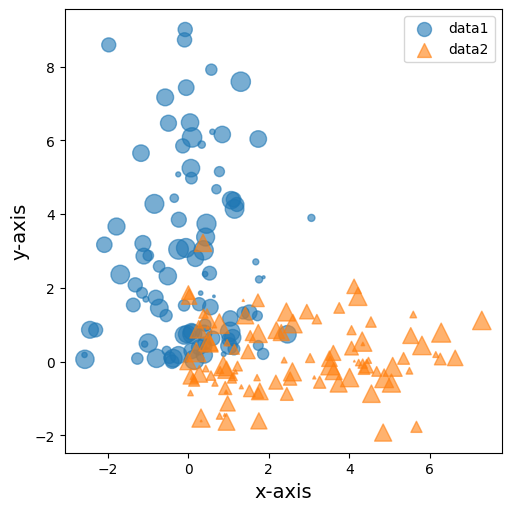

In [88]:
fig, ax = plt.subplots(figsize=(5, 5), layout='constrained')

ax.scatter(x=ran_data[0], y=ran_data[1], marker='o', s=scale1,
            alpha=0.6, label="data1")
ax.scatter(x=ran_data2[0], y=ran_data2[1], marker='^', s=scale2,
            alpha=0.6, label="data2")
ax.set_xlabel("x-axis", fontsize=14)
ax.set_ylabel("y-axis", fontsize=14)
ax.legend(fontsize=10)

plt.show()

When creating a simple plot, there is no obvious advantage to favoring this style. However, when making more complex figures with multiple panels, it can be very advantages and at times required to take this approach.

Here is an example, where we are going to create two panels to compare things side by side, without placing them all in the same figure and avoid overloading it.



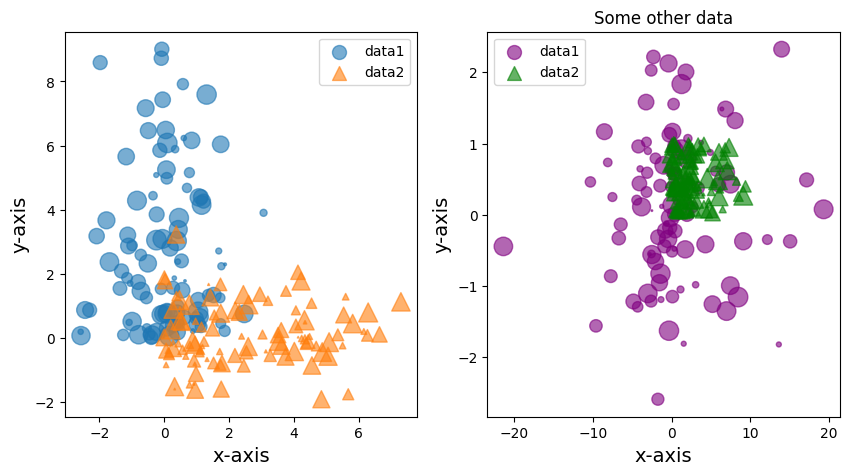

In [106]:
ran_data3 = [np.random.randn(N) * np.arange(0,10,10/N), np.random.randn(N)]
ran_data4 = [np.random.rand(N) * np.arange(0,10,10/N), np.random.rand(N)]
scale3 = 200 * np.random.rand(N)
scale4 = 200 * np.random.rand(N)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.scatter(x=ran_data[0], y=ran_data[1], marker='o', s=scale1,
            alpha=0.6, label="data1")
ax1.scatter(x=ran_data2[0], y=ran_data2[1], marker='^', s=scale2,
            alpha=0.6, label="data2")
ax1.set_xlabel("x-axis", fontsize=14)
ax1.set_ylabel("y-axis", fontsize=14)
ax2.set_title("Some data")
ax1.legend(fontsize=10)

ax2.scatter(x=ran_data3[0], y=ran_data3[1], marker='o', s=scale3,
            c='purple', alpha=0.6, label="data1", )
ax2.scatter(x=ran_data4[0], y=ran_data4[1], marker='^', s=scale4,
            c='g', alpha=0.6, label="data2")
ax2.set_xlabel("another x-axis", fontsize=14)
ax2.set_ylabel("another y-axis", fontsize=14)
ax2.set_title("Some other data")
ax2.legend(fontsize=10)

plt.show()

As you can imagine, there are ways to now share the y-axis, create many more panels etc. etc. We will not exploring these here further. Instead, let us look at a final use-case on the basis of a 3-D plot, just to give you an idea. If you don't understand this plot, don't worry, because we won't be looking at more 3-D plots further, but in principle you should now be ready to understand eveyr single line by itself at this point.

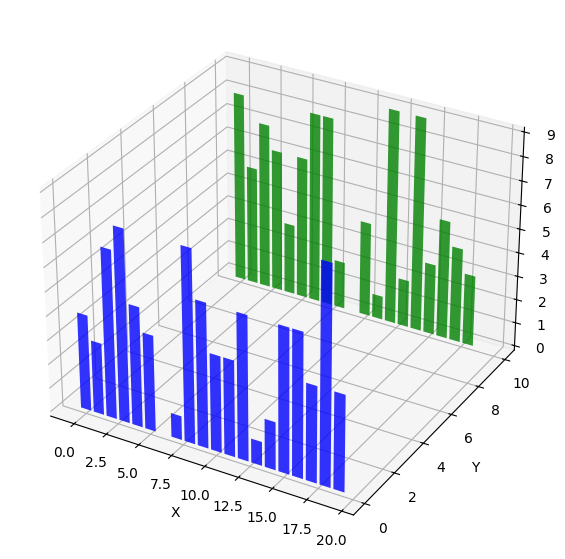

In [8]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
for idx,(c, z) in enumerate(zip(['g', 'b'], [10, 0])):
    xs = np.arange(len(random_data[0]))
    ys = random_data[idx]

    cs = [c] * len(xs)
    ax.bar(xs, ys, zs=z, zdir='y', color=cs, alpha=0.8)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.show()

# Exercise: Visualizing Simple Data Distributions
Let us start by visualizing a Gaussian distribution to explore how the function's parameters affect shape and spread

As a reminder, a Gaussian distribution is defined as
\begin{equation}
    p(x) = \frac{1}{\sqrt{2\pi\sigma^2}}\exp \left( - \frac{(x - \mu)^2}{2 \sigma^2} \right)
\end{equation}
where $\mu$ (greek: mu) represents the "mean" or center of the distribution, and $\sigma$ (greek: sigma) corresponds to the "standard deviation", controlling the spread.



### TO-DO
Using what you have learned so far and adopting one of the two coding-styles for plotting (both work equally well in the below case), do the following:

*   Define an array of equally spaced integers lying in the range of [-r,r]. *You can make use of the numpy linspace function for this purpose. Sensibel values for r could be at least 4 times the below chosen sigma.*
*   Define the above mathematical equation in code. It may be helpful to define separate variables for the normalization in the denominator and the argument of the exponential function. *You can use the numpy "sqrt" and "exp" functions for these parts respectively.*
* For each of your equally spread array entries, determine the value of the function. *It will be helpful to define a function for your mathematical expression that takes x, mu, and sigma as arguments*
*  Use the matplotlib library to visually compare three distributions with mean, sigma = (0, 1), (0, 2), (2, 1). *The simple matplotlib "plot" function is sufficient for this purpose*



In [1]:
# add your solution here 

### Visualizing distributions from empirical numbers

In practice, for instance in Data Science or Machine Learning, we often don't have a function for which we want to compute the output, but rather data for which we want to fit a function.

This means that some sensor or observation is going to provide you with many values that you can load into your code using the knowledge acquired in the data loading section. Here, let's emulate such data and see how to visualize it.


### TO-DO ###
We will draw random numbers from a function contained in Numpy, compute the mean and standard deviation of it, and then visualize the numbers as a Histogram.

*   When drawing numbers it helps to set a so called "seed", a value that makes the random number generator deterministic and thus reproducible. Set a seed. *We can make use of the numpy.random.seed function for this purpose*
*   Simulate 1000 data points drawn uniformly at random. Instead of spacing them equally by design, let's now instead draw them from a uniform distribution. *We can make use of the numpy.random.uniform function for this purpose.*
* Calculate the mean and standard deviation (mu, sigma) of your data by implementing a respective function and a for loop. *As a reminder, the mean is the average value and the std can be obtained by subtracting it from every data item and taking a normalized square root (variance without square root):* $$std = \sqrt{\frac{\sum_{i=1}^n (x_i - \bar{x})^2}{n}}$$ *Remember that the square root can also be expressed as a power of 0.5.*
* Double check your result's correctness by also using the numpy.mean() and numpy.std() functions
* Visualize your data using a histogram (bar) plot. *The matplotlib function .hist() will be useful for this purpose and you can use a bin size of 50*

In [2]:
# add your solution here 

### Advanced topic exercise: why visualization matters
If you are already done with the earlier exercise, try to give the following data a shot in visualization:

In above example, we could see that we made a terribly wrong assumption. We calculated the mean and the standard deviation, assuming our data could be normally distributed, yet it clearly is not. Visualiation can provide a good toolbox to help us gain understanding where numbers alone are insufficient.

To understand this even further, let us take a loot at the famous Anscombe Quartet. Below there are four datasets provided for you.

* Try plotting a figure with 4 panels (subplots), each visualizing one of the datasets as a scatterplot.
* Try sharing the y-axis and x-axis for pairs of plots respectively, so you don't need to repeat them.
* To avoid copy pasting the same code over and over, try creating an array of axis object and loop over them to fill the respective subplots with the correct data

In [3]:
x = [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5]
y1 = [8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68]
y2 = [9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74]
y3 = [7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73]
x4 = [8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8]
y4 = [6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89]

datasets = {
    'I': (x, y1),
    'II': (x, y2),
    'III': (x, y3),
    'IV': (x4, y4)
}

# add your solution here 